# Fase 1 — GSE142077: RNA-Seq IRI nel rene umano

**Dataset:** GSE142077 — Park et al., BMC Nephrology 2020  
**Tipo:** RNA-seq (Salmon quant.sf)  
**Design:** 5 pazienti × 3 condizioni (pre-ischemia, ischemia, riperfusione) — **paired design**  
**Confronto pipeline:** Reperfusion vs Pre-ischemia  
**Piattaforma:** Illumina HiSeq 2500, GRCh38.p13  

### Riferimenti dall'articolo
- 603 DEG ischemia vs pre-ischemia (402 up, 201 down)
- 1389 DEG reperfusion vs pre-ischemia (1119 up, 270 down)
- Criteri originali: |log2FC| ≥ 1, p < 0.05
- Pathway chiave: metabolismo (ischemia), immune response e cell migration (riperfusione)

In [1]:
# Setup
import pandas as pd
import numpy as np
import gzip
import tarfile
import os
import re
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Paths

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR     = PROJECT_ROOT / "data/geo/GSE142077"
OUTPUT_DIR   = PROJECT_ROOT / "output/fase1/GSE142077"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Directories create.")
print(f"Metti GSE142077_RAW.tar in: {DATA_DIR}/")

Directories create.
Metti GSE142077_RAW.tar in: /Users/robertocasale/Desktop/lavoro_FBF/magic_solution/data/geo/GSE142077/


## 1. Metadata dal Series Matrix

Estraiamo i metadati (GSM ID, condizione, paziente) dal file series_matrix.

In [2]:
# Parsing series matrix per metadata
# Adatta il path al tuo file
SERIES_MATRIX = DATA_DIR / "GSE142077_series_matrix.txt.gz"

# Se il file è altrove, aggiorna:
# SERIES_MATRIX = Path("percorso/al/file/GSE142077_series_matrix.txt.gz")

sample_meta = {}
with gzip.open(SERIES_MATRIX, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('!Sample_geo_accession'):
            gsm_ids = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_title'):
            titles = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_characteristics_ch1') and 'condition' in line:
            conditions = [x.strip('"').replace('condition: ', '') for x in line.split('\t')[1:]]

meta = pd.DataFrame({
    'gsm': gsm_ids,
    'title': titles,
    'condition': conditions
})

# Estrai patient ID dal title (es. P-IRI-h-2 → 2)
meta['patient'] = meta['title'].str.extract(r'(\d+)$').astype(int)

# Mappa condizione a label standard
cond_map = {'pre-ischemia': 'Pre-ischemia', 'ischemia': 'Ischemia', 'reperfusion': 'Reperfusion'}
meta['condition_std'] = meta['condition'].map(cond_map)

print(f"Campioni totali: {len(meta)}")
print(f"Pazienti unici: {meta['patient'].nunique()} → {sorted(meta['patient'].unique())}")
print(f"\nDistribuzione condizioni:")
print(meta['condition_std'].value_counts())
print(f"\n--- Metadata completa ---")
meta

Campioni totali: 15
Pazienti unici: 5 → [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Distribuzione condizioni:
condition_std
Pre-ischemia    5
Ischemia        5
Reperfusion     5
Name: count, dtype: int64

--- Metadata completa ---


,gsm,title,condition,patient,condition_std
0,GSM4219560,P-IRI-h-2,pre-ischemia,2,Pre-ischemia
1,GSM4219561,I-IRI-h-2,ischemia,2,Ischemia
2,GSM4219562,R10-IRI-h-2,reperfusion,2,Reperfusion
3,GSM4219563,P-IRI-h-3,pre-ischemia,3,Pre-ischemia
4,GSM4219564,I-IRI-h-3,ischemia,3,Ischemia
5,GSM4219565,R10-IRI-h-3,reperfusion,3,Reperfusion
6,GSM4219566,P-IRI-h-4,pre-ischemia,4,Pre-ischemia
7,GSM4219567,I-IRI-h-4,ischemia,4,Ischemia
8,GSM4219568,R10-IRI-h-4,reperfusion,4,Reperfusion
9,GSM4219569,P-IRI-h-5,pre-ischemia,5,Pre-ischemia


In [3]:
# VERIFICA 1: corrispondenza con articolo
assert len(meta) == 15, f"Attesi 15 campioni, trovati {len(meta)}"
assert meta['patient'].nunique() == 5, f"Attesi 5 pazienti, trovati {meta['patient'].nunique()}"
assert set(meta['condition_std']) == {'Pre-ischemia', 'Ischemia', 'Reperfusion'}
for p in meta['patient'].unique():
    n = len(meta[meta['patient'] == p])
    assert n == 3, f"Paziente {p} ha {n} campioni, attesi 3"
print("✅ Verifica metadata: 5 pazienti × 3 condizioni = 15 campioni — OK")

✅ Verifica metadata: 5 pazienti × 3 condizioni = 15 campioni — OK


## 2. Caricamento Salmon quant.sf files

I file quant.sf di Salmon contengono:
- `Name`: transcript ID (formato GENCODE con gene symbol)
- `NumReads`: estimated counts (usati per DE)
- `TPM`: transcripts per million

Dobbiamo:
1. Estrarre i file dal TAR
2. Parsare ogni quant.sf
3. Aggregare transcript → gene (sommando NumReads)

In [4]:
# Estrai TAR se non già fatto
TAR_FILE = DATA_DIR / "GSE142077_RAW.tar"
QUANT_DIR = DATA_DIR / "quant_files"

if not QUANT_DIR.exists():
    QUANT_DIR.mkdir()
    print(f"Estrazione {TAR_FILE}...")
    with tarfile.open(TAR_FILE, 'r') as tar:
        tar.extractall(QUANT_DIR)
    print(f"Estratti {len(list(QUANT_DIR.glob('*')))} file")
else:
    print(f"File già estratti in {QUANT_DIR}")

# Lista file
sf_files = sorted(QUANT_DIR.glob("*.sf.txt.gz"))
print(f"\nFile quant.sf trovati: {len(sf_files)}")
for f in sf_files:
    print(f"  {f.name}")

File già estratti in /Users/robertocasale/Desktop/lavoro_FBF/magic_solution/data/geo/GSE142077/quant_files

File quant.sf trovati: 15
  GSM4219560_P_2_quant.sf.txt.gz
  GSM4219561_I_2_quant.sf.txt.gz
  GSM4219562_R_2_quant.sf.txt.gz
  GSM4219563_P_3_quant.sf.txt.gz
  GSM4219564_I_3_quant.sf.txt.gz
  GSM4219565_R_3_quant.sf.txt.gz
  GSM4219566_P_4_quant.sf.txt.gz
  GSM4219567_I_4_quant.sf.txt.gz
  GSM4219568_R_4_quant.sf.txt.gz
  GSM4219569_P_5_quant.sf.txt.gz
  GSM4219570_I_5_quant.sf.txt.gz
  GSM4219571_R_5_quant.sf.txt.gz
  GSM4219572_P_6_quant.sf.txt.gz
  GSM4219573_R_6_quant.sf.txt.gz
  GSM4219574_I_6_quant.sf.txt.gz


In [5]:
# Mappa GSM → file quant.sf
gsm_to_file = {}
for f in sf_files:
    # Filename: GSM4219560_P_2_quant.sf.txt.gz
    gsm = f.name.split('_')[0]
    gsm_to_file[gsm] = f

# Verifica che tutti i GSM siano mappati
missing = [g for g in meta['gsm'] if g not in gsm_to_file]
if missing:
    print(f"⚠️ GSM senza file: {missing}")
else:
    print(f"✅ Tutti i {len(meta)} GSM mappati a file quant.sf")

✅ Tutti i 15 GSM mappati a file quant.sf


In [6]:
# Ispezione di un file quant.sf per capire la struttura
sample_file = list(gsm_to_file.values())[0]
df_sample = pd.read_csv(sample_file, sep='\t', compression='gzip')
print(f"File: {sample_file.name}")
print(f"Colonne: {list(df_sample.columns)}")
print(f"Righe (trascritti): {len(df_sample)}")
print(f"\nPrime 5 righe:")
df_sample.head()

File: GSM4219560_P_2_quant.sf.txt.gz
Colonne: ['Name', 'Length', 'EffectiveLength', 'TPM', 'NumReads']
Righe (trascritti): 226608

Prime 5 righe:


,Name,Length,EffectiveLength,TPM,NumReads
0,ENST00000456328.2|ENSG00000223972.5|OTTHUMG000...,1657,1679.387,0.315355,9.821
1,ENST00000450305.2|ENSG00000223972.5|OTTHUMG000...,632,461.000,0.000000,0.000
2,ENST00000488147.1|ENSG00000227232.5|OTTHUMG000...,1351,1757.563,10.100741,329.201
3,ENST00000619216.1|ENSG00000278267.1|-|-|MIR685...,68,1.000,0.000000,0.000
4,ENST00000473358.1|ENSG00000243485.5|OTTHUMG000...,712,509.438,0.000000,0.000


In [7]:
# Parsing del campo Name per estrarre gene symbol
# Formato: ENST...|ENSG...|OTTHUMG...|OTTHUMT...|transcript_name|GENE_SYMBOL|length|biotype|
# Il gene symbol è al 6° campo (indice 5)

def extract_gene_symbol(name_field):
    """Estrai gene symbol dal campo Name di Salmon quant.sf (formato GENCODE)"""
    parts = name_field.split('|')
    if len(parts) >= 6:
        return parts[5]  # Gene symbol
    return None

# Test
test_names = df_sample['Name'].head(5)
for n in test_names:
    print(f"{extract_gene_symbol(n):15s} ← {n[:80]}...")

DDX11L1         ← ENST00000456328.2|ENSG00000223972.5|OTTHUMG00000000961.2|OTTHUMT00000362751.1|DD...
DDX11L1         ← ENST00000450305.2|ENSG00000223972.5|OTTHUMG00000000961.2|OTTHUMT00000002844.2|DD...
WASH7P          ← ENST00000488147.1|ENSG00000227232.5|OTTHUMG00000000958.1|OTTHUMT00000002839.1|WA...
MIR6859-1       ← ENST00000619216.1|ENSG00000278267.1|-|-|MIR6859-1-201|MIR6859-1|68|miRNA|...
MIR1302-2HG     ← ENST00000473358.1|ENSG00000243485.5|OTTHUMG00000000959.2|OTTHUMT00000002840.1|MI...


In [8]:
# Carica tutti i file e aggrega transcript → gene (somma NumReads)
print("Caricamento e aggregazione transcript → gene...")

counts_dict = {}  # gene → {gsm: count}
tpm_dict = {}     # gene → {gsm: tpm} (per export Fase 2)

for gsm in meta['gsm']:
    fpath = gsm_to_file[gsm]
    df = pd.read_csv(fpath, sep='\t', compression='gzip')
    df['gene'] = df['Name'].apply(extract_gene_symbol)
    df = df.dropna(subset=['gene'])
    
    # Aggrega per gene: somma NumReads, somma TPM
    gene_counts = df.groupby('gene')['NumReads'].sum()
    gene_tpm = df.groupby('gene')['TPM'].sum()
    
    counts_dict[gsm] = gene_counts
    tpm_dict[gsm] = gene_tpm

# Costruisci matrice counts (gene × sample)
counts_matrix = pd.DataFrame(counts_dict).fillna(0)
tpm_matrix = pd.DataFrame(tpm_dict).fillna(0)

print(f"Matrice counts: {counts_matrix.shape[0]} geni × {counts_matrix.shape[1]} campioni")
print(f"\nPrime 5 righe counts:")
display(counts_matrix.head())
print(f"Matrice TPM: {tpm_matrix.shape[0]} geni × {tpm_matrix.shape[1]} campioni")
print(f"\nPrime 5 righe TPM:")
display(tpm_matrix.head())

Caricamento e aggregazione transcript → gene...
Matrice counts: 59033 geni × 15 campioni

Prime 5 righe counts:


,GSM4219560,GSM4219561,GSM4219562,GSM4219563,GSM4219564,GSM4219565,GSM4219566,GSM4219567,GSM4219568,GSM4219569,GSM4219570,GSM4219571,GSM4219572,GSM4219573,GSM4219574
gene,,,,,,,,,,,,,,,
5S_rRNA,0.000,0.000,0.00,0.000,0.000,0.00,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5_8S_rRNA,0.000,0.000,0.00,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7SK,0.000,0.000,1.00,2.000,0.000,1.00,1.000,0.000,5.661,2.836,2.000,1.000,1.000,0.000,0.000
A1BG,39.975,28.998,17.04,16.021,16.453,22.32,29.937,26.066,40.890,23.443,10.421,15.682,27.109,13.028,36.162
A1BG-AS1,94.001,55.000,27.00,29.303,29.000,30.00,102.000,48.000,76.000,40.000,13.000,23.000,45.000,19.000,39.000


Matrice TPM: 59033 geni × 15 campioni

Prime 5 righe TPM:


,GSM4219560,GSM4219561,GSM4219562,GSM4219563,GSM4219564,GSM4219565,GSM4219566,GSM4219567,GSM4219568,GSM4219569,GSM4219570,GSM4219571,GSM4219572,GSM4219573,GSM4219574
gene,,,,,,,,,,,,,,,
5S_rRNA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.540094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5_8S_rRNA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7SK,0.000000,0.000000,0.504199,1.138264,0.000000,0.535910,0.802503,0.000000,4.275273,2.124501,0.706530,0.379255,0.322769,0.000000,0.000000
A1BG,5.112040,1.829773,1.543182,1.509837,2.058317,1.680198,4.208784,3.264965,5.391924,2.800161,0.163182,0.239961,2.653566,0.497640,1.626588
A1BG-AS1,2.620565,1.659643,0.584703,0.816245,0.748329,0.773248,4.070522,2.037718,2.505905,1.254696,0.177193,0.305643,0.900105,0.273674,0.863271


In [9]:
# VERIFICA 2: statistiche base dei counts
print("=== Statistiche counts per campione ===")
for gsm in meta['gsm']:
    title = meta[meta['gsm'] == gsm]['title'].values[0]
    total = counts_matrix[gsm].sum()
    nonzero = (counts_matrix[gsm] > 0).sum()
    print(f"  {gsm} ({title:15s}): {total:,.0f} reads totali, {nonzero:,} geni espressi")

print(f"\nGeni totali nella matrice: {counts_matrix.shape[0]}")
print(f"Geni con almeno 1 read in almeno 1 campione: {(counts_matrix.sum(axis=1) > 0).sum()}")

=== Statistiche counts per campione ===
  GSM4219560 (P-IRI-h-2      ): 23,601,550 reads totali, 28,706 geni espressi
  GSM4219561 (I-IRI-h-2      ): 21,696,703 reads totali, 28,575 geni espressi
  GSM4219562 (R10-IRI-h-2    ): 23,357,292 reads totali, 28,599 geni espressi
  GSM4219563 (P-IRI-h-3      ): 22,920,424 reads totali, 28,765 geni espressi
  GSM4219564 (I-IRI-h-3      ): 21,145,190 reads totali, 29,206 geni espressi
  GSM4219565 (R10-IRI-h-3    ): 24,153,645 reads totali, 29,153 geni espressi
  GSM4219566 (P-IRI-h-4      ): 21,142,163 reads totali, 30,188 geni espressi
  GSM4219567 (I-IRI-h-4      ): 21,324,971 reads totali, 30,161 geni espressi
  GSM4219568 (R10-IRI-h-4    ): 21,915,049 reads totali, 30,586 geni espressi
  GSM4219569 (P-IRI-h-5      ): 21,098,065 reads totali, 30,375 geni espressi
  GSM4219570 (I-IRI-h-5      ): 31,833,779 reads totali, 28,567 geni espressi
  GSM4219571 (R10-IRI-h-5    ): 30,901,580 reads totali, 29,309 geni espressi
  GSM4219572 (P-IRI-h-6 

## 3. Preprocessing

Per pyDESeq2 servono counts interi. Salmon produce NumReads frazionari; li arrotondiamo.
Filtriamo geni con espressione troppo bassa.

In [10]:
# STEP 1: Arrotonda counts a interi (Salmon produce frazioni da EM algorithm)
counts_int = counts_matrix.round().astype(int)

# STEP 2: Filtro geni lowly expressed
# Criterio: almeno 5 reads in almeno 3 campioni (= min n per gruppo)
MIN_READS = 5
MIN_SAMPLES = 3
keep = (counts_int >= MIN_READS).sum(axis=1) >= MIN_SAMPLES
counts_filt = counts_int[keep]

print(f"Geni prima del filtro: {len(counts_int):,}")
print(f"Geni dopo filtro (≥{MIN_READS} reads in ≥{MIN_SAMPLES} campioni): {len(counts_filt):,}")
print(f"Geni rimossi: {len(counts_int) - len(counts_filt):,}")

Geni prima del filtro: 59,033
Geni dopo filtro (≥5 reads in ≥3 campioni): 25,222
Geni rimossi: 33,811


In [11]:
# Check date Excel
import re
date_pattern = re.compile(r"^\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$", re.IGNORECASE)
corrupted = [val for val in counts_filt.index.dropna().astype(str) if date_pattern.match(val)]
if not corrupted:
    print("✅ Nessuna data Excel trovata nei nomi dei geni.")
else:
    print(f"❌ Date Excel trovate: {set(corrupted)}")

✅ Nessuna data Excel trovata nei nomi dei geni.


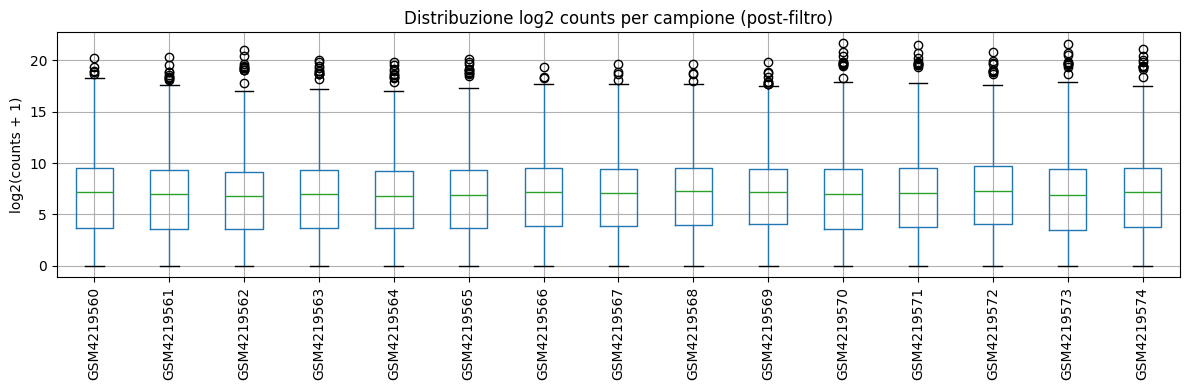

In [12]:
# Distribuzione log2(counts+1) per campione — quick check
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
log_counts = np.log2(counts_filt + 1)
log_counts.boxplot(ax=ax, rot=90)
ax.set_ylabel('log2(counts + 1)')
ax.set_title('Distribuzione log2 counts per campione (post-filtro)')
plt.tight_layout()
plt.show()

## 4. Definizione gruppi e design

**Confronto per la pipeline:** Reperfusion vs Pre-ischemia  
**Design:** paired (stesso paziente in entrambe le condizioni)  

Per pyDESeq2 usiamo solo i 10 campioni (5 Pre-ischemia + 5 Reperfusion).  
Il paziente viene incluso come covariate per il paired design.

In [13]:
# Seleziona solo Pre-ischemia e Reperfusion
meta_pr = meta[meta['condition_std'].isin(['Pre-ischemia', 'Reperfusion'])].copy()
meta_pr = meta_pr.set_index('gsm')

# Ordina per paziente e condizione
meta_pr = meta_pr.sort_values(['patient', 'condition_std'])

print(f"Campioni per DE: {len(meta_pr)}")
print(f"  Pre-ischemia: {(meta_pr['condition_std'] == 'Pre-ischemia').sum()}")
print(f"  Reperfusion:  {(meta_pr['condition_std'] == 'Reperfusion').sum()}")
print(f"\nPairing:")
for p in sorted(meta_pr['patient'].unique()):
    sub = meta_pr[meta_pr['patient'] == p]
    print(f"  Paziente {p}: {', '.join(sub.index)} ({', '.join(sub['condition_std'])})")

Campioni per DE: 10
  Pre-ischemia: 5
  Reperfusion:  5

Pairing:
  Paziente 2: GSM4219560, GSM4219562 (Pre-ischemia, Reperfusion)
  Paziente 3: GSM4219563, GSM4219565 (Pre-ischemia, Reperfusion)
  Paziente 4: GSM4219566, GSM4219568 (Pre-ischemia, Reperfusion)
  Paziente 5: GSM4219569, GSM4219571 (Pre-ischemia, Reperfusion)
  Paziente 6: GSM4219572, GSM4219573 (Pre-ischemia, Reperfusion)


In [14]:
# Prepara matrice counts per pyDESeq2 (solo campioni P e R)
gsm_pr = list(meta_pr.index)
counts_de = counts_filt[gsm_pr].T  # pyDESeq2 vuole samples × genes

# Clinical data per pyDESeq2
clinical = meta_pr[['condition_std', 'patient']].copy()
clinical.columns = ['condition', 'patient']
clinical['patient'] = clinical['patient'].astype(str)  # fattore

# Verifica allineamento
assert list(counts_de.index) == list(clinical.index), "Mismatch indici!"
print(f"Matrice DE: {counts_de.shape[0]} campioni × {counts_de.shape[1]} geni")
print(f"\nClinical data:")
clinical

Matrice DE: 10 campioni × 25222 geni

Clinical data:


,condition,patient
gsm,,
GSM4219560,Pre-ischemia,2
GSM4219562,Reperfusion,2
GSM4219563,Pre-ischemia,3
GSM4219565,Reperfusion,3
GSM4219566,Pre-ischemia,4
GSM4219568,Reperfusion,4
GSM4219569,Pre-ischemia,5
GSM4219571,Reperfusion,5
GSM4219572,Pre-ischemia,6


## 5. Espressione Differenziale con pyDESeq2

Design: `~ patient + condition` (paired, paziente come covariate)  
Confronto: Reperfusion vs Pre-ischemia

In [15]:
# Geni con zero in almeno un campione vs geni senza zeri (controllo per DeseqDataSet di pydeseq2)
n_any_zero = (counts_de == 0).any(axis=0).sum()
n_all_nonzero = (counts_de > 0).all(axis=0).sum()
print(f"Geni con almeno uno zero: {n_any_zero}")
print(f"Geni senza zeri in nessun campione: {n_all_nonzero}")

Geni con almeno uno zero: 2979
Geni senza zeri in nessun campione: 22243


In [16]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("Inizializzazione DESeq2 dataset...")
dds = DeseqDataSet(
    counts=counts_de,
    metadata=clinical,
    design='~ patient + condition',
    refit_cooks=True
)

print("Fitting DESeq2 (può richiedere qualche minuto)...")
dds.deseq2()
print("✅ DESeq2 fitting completato")

Inizializzazione DESeq2 dataset...
Fitting DESeq2 (può richiedere qualche minuto)...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 11.75 seconds.

Fitting dispersion trend curve...
... done in 1.35 seconds.

Fitting MAP dispersions...
... done in 14.57 seconds.

Fitting LFCs...


✅ DESeq2 fitting completato


... done in 14.04 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 0 outlier genes.



In [17]:
sf = pd.Series(dds.obsm['size_factors'] if 'size_factors' in dds.obsm else dds.obs['size_factors'])
print(f"Size factors: min={sf.min():.2f}, median={sf.median():.2f}, max={sf.max():.2f}")

Size factors: min=0.83, median=1.03, max=1.19


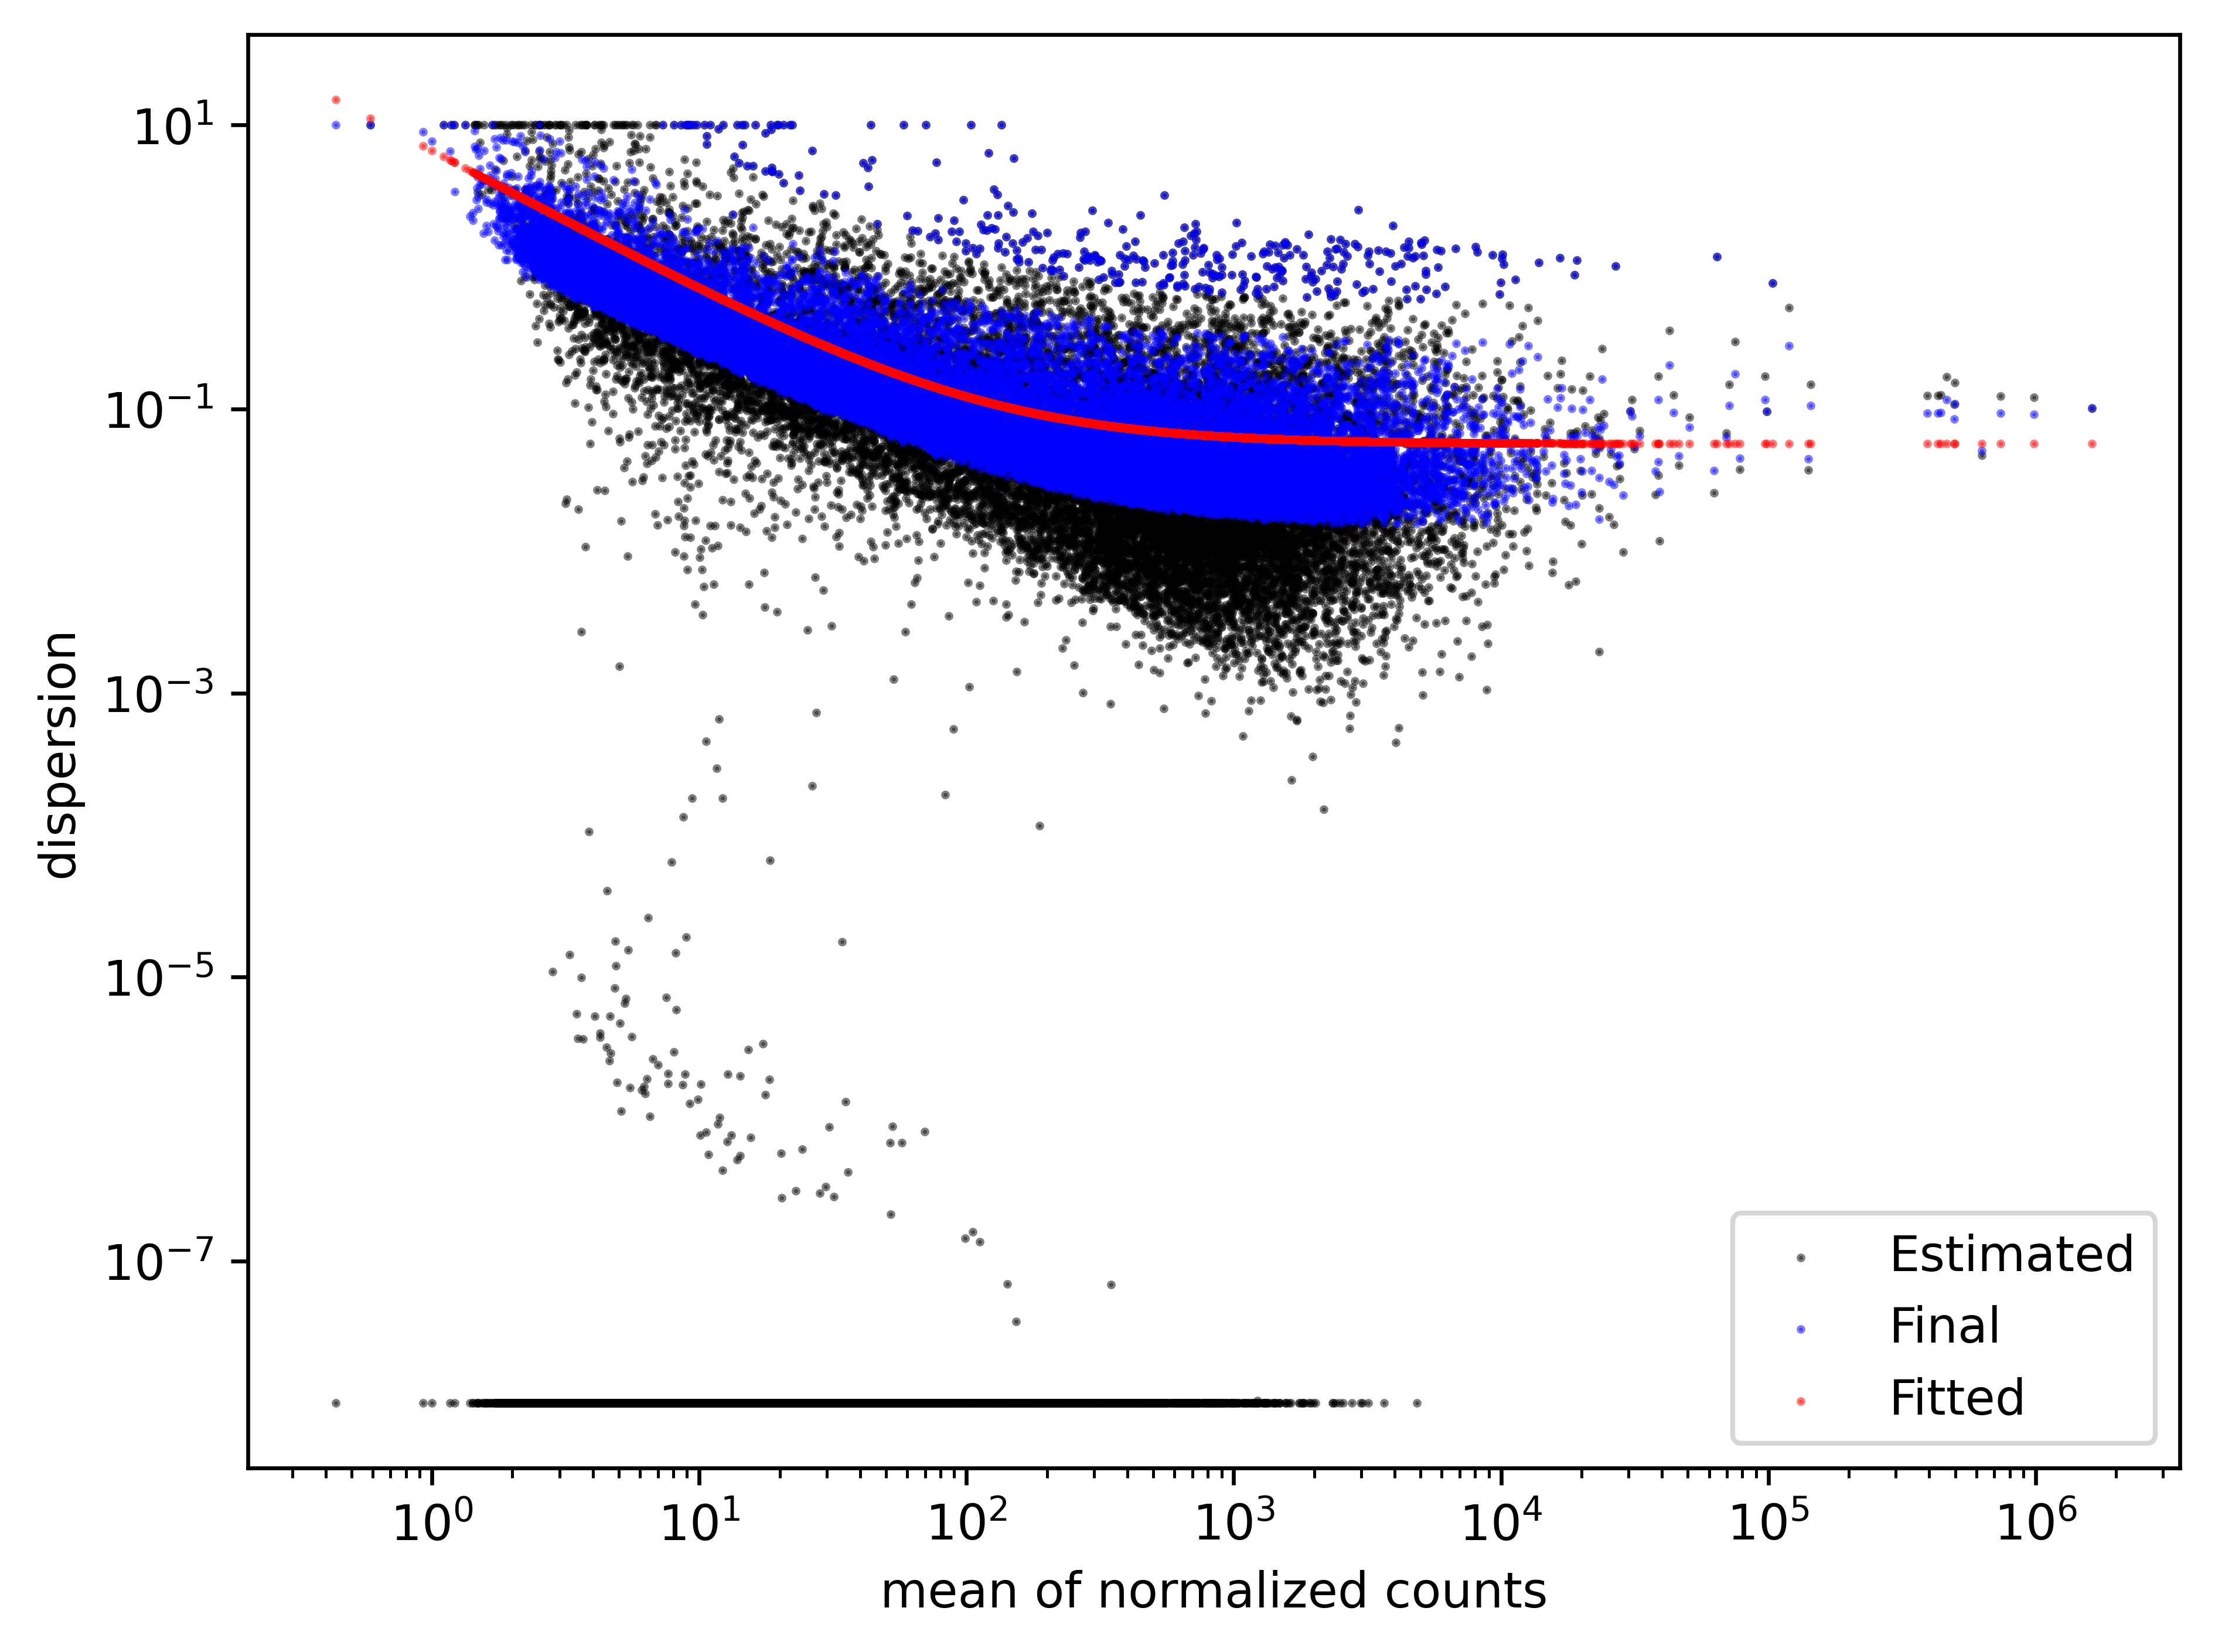

In [18]:
dds.plot_dispersions()

In [19]:
# Estrai risultati: Reperfusion vs Pre-ischemia
stat_res = DeseqStats(dds, contrast=['condition', 'Reperfusion', 'Pre-ischemia'])
stat_res.summary()

results = stat_res.results_df.copy()
results.index.name = 'gene'

print(f"\nRisultati: {len(results)} geni")
print(f"\nColonne: {list(results.columns)}")
results.head(10)

Running Wald tests...
... done in 4.06 seconds.



Log2 fold change & Wald test p-value: condition Reperfusion vs Pre-ischemia
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene                                                                          
A1BG         23.806472       -0.195035  0.421547 -0.462664  0.643605  0.901046
A1BG-AS1     46.564031       -0.668948  0.339709 -1.969178  0.048933  0.337998
A1CF        589.408078        3.351958  1.094242  3.063270  0.002189  0.061597
A2M       18738.651533       -0.232227  0.229508 -1.011848  0.311611  0.723674
A2M-AS1      63.926122       -0.434409  0.255300 -1.701563  0.088837  0.444186
...                ...             ...       ...       ...       ...       ...
ZXDC        968.349250        0.148488  0.162048  0.916320  0.359499  0.758259
ZYG11A      144.009114        2.075818  0.465970  4.454829  0.000008  0.001921
ZYG11B     1089.037839        0.313105  0.206699  1.514791  0.129825  0.525135
ZYX        3434.974748       -0.201419  0.274888 -0.732

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
A1BG,23.806472,-0.195035,0.421547,-0.462664,0.643605,0.901046
A1BG-AS1,46.564031,-0.668948,0.339709,-1.969178,0.048933,0.337998
A1CF,589.408078,3.351958,1.094242,3.063270,0.002189,0.061597
A2M,18738.651533,-0.232227,0.229508,-1.011848,0.311611,0.723674
A2M-AS1,63.926122,-0.434409,0.255300,-1.701563,0.088837,0.444186
A2MP1,7.176979,-0.407057,0.757878,-0.537101,0.591198,NaN
A4GALT,551.692006,0.489597,0.296388,1.651882,0.098559,0.466998
AAAS,977.261545,-0.032307,0.137542,-0.234890,0.814294,0.957806
AACS,777.831003,-0.357064,0.181604,-1.966165,0.049280,0.338838


In [20]:
# Statistiche DE con soglie dell'articolo originale (|log2FC| ≥ 1, p < 0.05)
sig_article = results[(results['pvalue'] < 0.05) & (results['log2FoldChange'].abs() >= 1)]
n_up_article = (sig_article['log2FoldChange'] > 0).sum()
n_down_article = (sig_article['log2FoldChange'] < 0).sum()

print("=== Confronto con articolo (Rep vs Pre, |log2FC|≥1, p<0.05) ===")
print(f"  Articolo: 1389 DEG (1119 up, 270 down)")
print(f"  Nostri:   {len(sig_article)} DEG ({n_up_article} up, {n_down_article} down)")
print(f"")

# Con soglie pipeline (|log2FC| > 0.379, FDR < 0.05)
sig_pipeline = results[(results['padj'] < 0.05) & (results['log2FoldChange'].abs() > 0.379)]
n_up_pipe = (sig_pipeline['log2FoldChange'] > 0).sum()
n_down_pipe = (sig_pipeline['log2FoldChange'] < 0).sum()

print(f"=== Soglie pipeline (|log2FC|>0.379, FDR<0.05) ===")
print(f"  {len(sig_pipeline)} DEG ({n_up_pipe} up, {n_down_pipe} down)")

=== Confronto con articolo (Rep vs Pre, |log2FC|≥1, p<0.05) ===
  Articolo: 1389 DEG (1119 up, 270 down)
  Nostri:   1434 DEG (1145 up, 289 down)

=== Soglie pipeline (|log2FC|>0.379, FDR<0.05) ===
  644 DEG (594 up, 50 down)


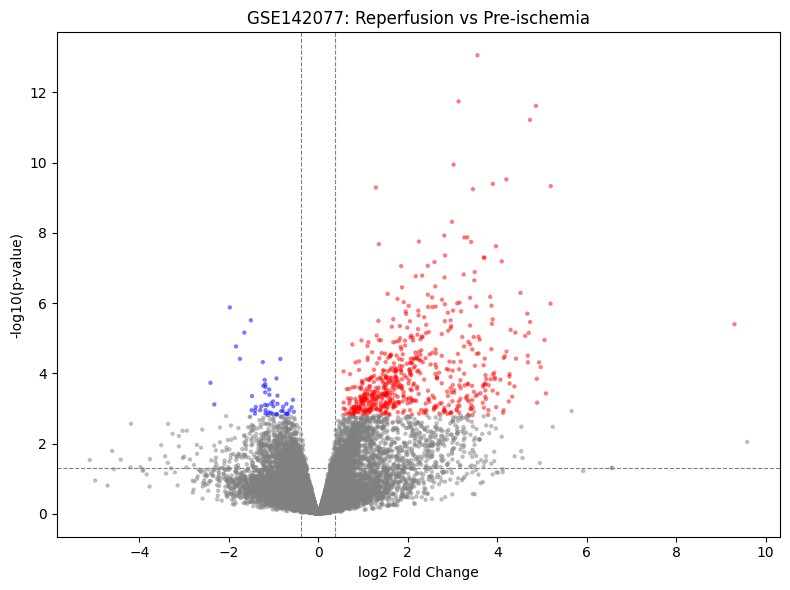

In [21]:
# Volcano plot
fig, ax = plt.subplots(figsize=(8, 6))

r = results.dropna(subset=['pvalue', 'log2FoldChange'])
r['-log10p'] = -np.log10(r['pvalue'].clip(lower=1e-300))

# Colori
colors = np.where(
    (r['padj'] < 0.05) & (r['log2FoldChange'] > 0.379), 'red',
    np.where(
        (r['padj'] < 0.05) & (r['log2FoldChange'] < -0.379), 'blue', 'grey'
    )
)

ax.scatter(r['log2FoldChange'], r['-log10p'], c=colors, alpha=0.4, s=5)
ax.axhline(-np.log10(0.05), ls='--', c='grey', lw=0.8)
ax.axvline(0.379, ls='--', c='grey', lw=0.8)
ax.axvline(-0.379, ls='--', c='grey', lw=0.8)
ax.set_xlabel('log2 Fold Change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('GSE142077: Reperfusion vs Pre-ischemia')
plt.tight_layout()
plt.show()

## 6. Formato output standard

Prepariamo il CSV nel formato richiesto dalla pipeline.

In [22]:
# Formato standard per la meta-analisi
de_output = results[['log2FoldChange', 'pvalue', 'padj']].copy()
de_output.columns = ['log2FoldChange', 'pvalue', 'padj']
de_output['comparison'] = 'Reperfusion_vs_PreIschemia'
de_output['dataset'] = 'GSE142077'
de_output.index.name = 'gene'

# Rimuovi geni con risultati NA
de_output = de_output.dropna(subset=['pvalue'])

print(f"Geni nel CSV finale: {len(de_output)}")
de_output.head(10)

Geni nel CSV finale: 25221


,log2FoldChange,pvalue,padj,comparison,dataset
gene,,,,,
A1BG,-0.195035,0.643605,0.901046,Reperfusion_vs_PreIschemia,GSE142077
A1BG-AS1,-0.668948,0.048933,0.337998,Reperfusion_vs_PreIschemia,GSE142077
A1CF,3.351958,0.002189,0.061597,Reperfusion_vs_PreIschemia,GSE142077
A2M,-0.232227,0.311611,0.723674,Reperfusion_vs_PreIschemia,GSE142077
A2M-AS1,-0.434409,0.088837,0.444186,Reperfusion_vs_PreIschemia,GSE142077
A2MP1,-0.407057,0.591198,NaN,Reperfusion_vs_PreIschemia,GSE142077
A4GALT,0.489597,0.098559,0.466998,Reperfusion_vs_PreIschemia,GSE142077
AAAS,-0.032307,0.814294,0.957806,Reperfusion_vs_PreIschemia,GSE142077
AACS,-0.357064,0.049280,0.338838,Reperfusion_vs_PreIschemia,GSE142077


## 7. Verifica geni chiave dall'articolo

Controlliamo che i geni citati nell'articolo mostrino le direzioni attese.

In [23]:
# Geni chiave citati nell'articolo (reperfusion vs pre-ischemia)
key_genes = {
    # Metabolismo (downregulated in IRI)
    'CYP1A2': 'down', 'CYP2C8': 'down', 'CYP2C9': 'down', 'CYP3A4': 'down',
    # Cell growth/migration (downregulated in reperfusion)
    'AKT1': 'down', 'AKT2': 'down', 'AKT3': 'down', 'KRAS': 'down',
    # Semaphorin signaling (downregulated)
    'SEMA4D': 'down', 'PLXNB1': 'down',
    # Immune/inflammasome (upregulated in reperfusion from SOM)
    'HLA-A': 'variable', 'HLA-B': 'variable',
    # Apoptosis markers (various in IRI)
    'FAS': 'down', 'TNF': 'down',
}

print(f"{'Gene':12s} {'log2FC':>8s} {'pvalue':>10s} {'padj':>10s} {'Atteso':>8s} {'Match':>6s}")
print("-" * 62)
found = 0
match = 0
for gene, expected in key_genes.items():
    if gene in de_output.index:
        row = de_output.loc[gene]
        fc = row['log2FoldChange']
        direction = 'down' if fc < 0 else 'up'
        ok = '✅' if expected == 'variable' or direction == expected else '⚠️'
        if ok == '✅': match += 1
        found += 1
        print(f"{gene:12s} {fc:8.3f} {row['pvalue']:10.2e} {row['padj']:10.2e} {expected:>8s} {ok:>6s}")
    else:
        print(f"{gene:12s} {'NOT FOUND':>8s}")

print(f"\nGeni trovati: {found}/{len(key_genes)}")
print(f"Direzione coerente: {match}/{found}")

Gene           log2FC     pvalue       padj   Atteso  Match
--------------------------------------------------------------
CYP1A2         -0.747   2.28e-01   6.49e-01     down      ✅
CYP2C8          1.261   2.15e-02   2.27e-01     down     ⚠️
CYP2C9          2.166   2.93e-03   7.32e-02     down     ⚠️
CYP3A4          3.872   1.18e-06   5.18e-04     down     ⚠️
AKT1           -0.044   7.65e-01   9.44e-01     down      ✅
AKT2           -0.084   6.69e-01   9.09e-01     down      ✅
AKT3           -0.066   6.47e-01   9.02e-01     down      ✅
KRAS           -0.049   7.77e-01   9.47e-01     down      ✅
SEMA4D         -0.258   1.46e-01   5.54e-01     down      ✅
PLXNB1         -0.060   6.68e-01   9.09e-01     down      ✅
HLA-A          -0.084   6.28e-01   8.95e-01 variable      ✅
HLA-B          -0.302   1.83e-01   6.03e-01 variable      ✅
FAS            -0.313   1.72e-01   5.88e-01     down      ✅
TNF            -1.132   4.75e-03   9.50e-02     down      ✅

Geni trovati: 14/14
Direzione coeren

In [24]:
# Top 20 DEG per significatività (pipeline thresholds)
top20 = de_output.dropna(subset=['padj']).sort_values('padj').head(20)
print("=== Top 20 geni più significativi (Reperfusion vs Pre-ischemia) ===")
print(top20[['log2FoldChange', 'pvalue', 'padj']].to_string())

=== Top 20 geni più significativi (Reperfusion vs Pre-ischemia) ===
            log2FoldChange        pvalue          padj
gene                                                  
PTPRQ             3.557341  8.718185e-14  1.815126e-09
DPP6              3.136247  1.796904e-12  1.661306e-08
SOST              4.865008  2.393813e-12  1.661306e-08
LINC01055         4.731403  6.021907e-12  3.134402e-08
TRIM50            3.023656  1.133404e-10  4.719494e-07
DDN               4.203654  2.981803e-10  1.034686e-06
NR4A3             1.287461  5.092560e-10  1.178079e-06
AC023154.1        5.195910  4.644783e-10  1.178079e-06
CALML3-AS1        3.902908  4.012096e-10  1.178079e-06
AC114291.1        3.458468  5.677713e-10  1.182100e-06
TENM2             2.989687  4.828077e-09  9.138232e-06
PTPRO             3.264601  1.348824e-08  2.005895e-05
GPD1              2.817071  1.185735e-08  2.005895e-05
REN               3.329198  1.336610e-08  2.005895e-05
SORCS1            3.416491  1.806285e-08  2.350429e-

## 8. Salvataggio

In [25]:
# === 8. Salvataggio ===

# 8a. DE per meta-analisi
de_output.to_csv(OUTPUT_DIR / "de_GSE142077_IRI_vs_Control.csv")
print(f"✅ DE: {len(de_output)} geni")

# 8b. Matrice counts (gene × sample, tutti i 15 campioni)
counts_filt.to_csv(OUTPUT_DIR / "expr_GSE142077.csv.gz", compression='gzip')
print(f"✅ Expr: {counts_filt.shape[0]} geni × {counts_filt.shape[1]} campioni")

# 8c. Sample labels (formato standard: sample, condition, patient, dataset)
sample_labels = pd.DataFrame({
    "sample": meta['gsm'],
    "condition": meta['condition_std'].map({
        'Pre-ischemia': 'Control', 'Ischemia': 'Ischemia', 'Reperfusion': 'IRI'
    }),
    "patient": meta['patient'].astype(str),
    "dataset": "GSE142077"
})
sample_labels.to_csv(OUTPUT_DIR / "sample_labels_GSE142077.csv", index=False)
print(f"✅ Labels: {len(sample_labels)} campioni")

✅ DE: 25221 geni
✅ Expr: 25222 geni × 15 campioni
✅ Labels: 15 campioni


In [26]:
# Riepilogo finale
print("=" * 60)
print("RIEPILOGO GSE142077 — Fase 1 completata")
print("=" * 60)
print(f"Dataset: GSE142077 (Park et al., BMC Nephrology 2020)")
print(f"Tipo: RNA-seq (Salmon quant.sf)")
print(f"Design: Paired, 5 pazienti × 3 condizioni")
print(f"Confronto DE: Reperfusion vs Pre-ischemia")
print(f"Geni testati: {len(de_output)}")

sig = de_output[(de_output['padj'] < 0.05) & (de_output['log2FoldChange'].abs() > 0.379)]
print(f"DEG (|log2FC|>0.379, FDR<0.05): {len(sig)} ({(sig['log2FoldChange']>0).sum()} up, {(sig['log2FoldChange']<0).sum()} down)")
print(f"")
print(f"File salvati:")
print(f"  {OUTPUT_DIR / 'de_GSE142077_IRI_vs_Control.csv'}")
print(f"  {OUTPUT_DIR / 'expr_GSE142077.csv.gz'}")
print(f"  {OUTPUT_DIR / 'sample_labels_GSE142077.csv'}")
print(f"")
print(f"Nota: i numeri DEG differiscono dall'articolo perché:")
print(f"  - Articolo usa p-value non corretto, noi usiamo FDR")
print(f"  - Articolo usa soglia |log2FC|≥1, noi |log2FC|>0.379")
print(f"  - Differenze minime nel preprocessing (arrotondamento counts)")

RIEPILOGO GSE142077 — Fase 1 completata
Dataset: GSE142077 (Park et al., BMC Nephrology 2020)
Tipo: RNA-seq (Salmon quant.sf)
Design: Paired, 5 pazienti × 3 condizioni
Confronto DE: Reperfusion vs Pre-ischemia
Geni testati: 25221
DEG (|log2FC|>0.379, FDR<0.05): 644 (594 up, 50 down)

File salvati:
  /Users/robertocasale/Desktop/lavoro_FBF/magic_solution/output/fase1/GSE142077/de_GSE142077_IRI_vs_Control.csv
  /Users/robertocasale/Desktop/lavoro_FBF/magic_solution/output/fase1/GSE142077/expr_GSE142077.csv.gz
  /Users/robertocasale/Desktop/lavoro_FBF/magic_solution/output/fase1/GSE142077/sample_labels_GSE142077.csv

Nota: i numeri DEG differiscono dall'articolo perché:
  - Articolo usa p-value non corretto, noi usiamo FDR
  - Articolo usa soglia |log2FC|≥1, noi |log2FC|>0.379
  - Differenze minime nel preprocessing (arrotondamento counts)
